# Classificacao EMNIST com MLP em PyTorch

Aluno: Vinicius de Lucena - RA 00376040

Neste notebook foram implementadas duas redes neurais totalmente conectadas
(MLP) para classificar os caracteres do EMNIST Balanced
(47 classes).

O codigo segue de perto o estilo dos notebooks da disciplina, em
particular o notebook de Fashion MNIST (aula 8) e o de TensorBoard
com classificacao binária.


## 1. Importações e configuração

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")


Device: cpu
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu


## 2. Pipeline de dados

### 2.1 Correção de orientação do EMNIST

Os arquivos binarios do EMNIST, como vem do torchvision, estão
armazenados com orientação rotacionada e espelhada em relação ao
formato que o olho humano reconhece. Será aplicado uma rotação
de -90 graus e um flip horizontal para que as imagens fiquem na
posição correta.


In [ ]:
class EMNISTCorrigido(Dataset):

    def __init__(self, dataset_base):
        self.base = dataset_base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        #img vem como tensor [1, 28, 28] depois do ToTensor
        img = torch.rot90(img, k=-1, dims=[-2, -1])
        img = torch.flip(img, dims=[-1])
        return img, label


### 2.2 Média e desvio padrão dos pixels

Para aplicar a normalização T.Normalize(media, desvio) precisamos
dos valores de media e desvio padrão dos pixels do conjunto de
treino.


In [ ]:
#primeiro carregamos o dataset apenas com ToTensor (pixels em [0, 1])
ds_para_calculo = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True,
    download=True, transform=T.ToTensor(),
)
ds_para_calculo = EMNISTCorrigido(ds_para_calculo)

loader_tmp = DataLoader(ds_para_calculo, batch_size=1024, shuffle=False)

soma, soma_quadrados, n_pixels = 0.0, 0.0, 0
for X, _ in loader_tmp:
    soma += X.sum().item()
    soma_quadrados += (X ** 2).sum().item()
    n_pixels += X.numel()

MEDIA = soma / n_pixels
DESVIO = (soma_quadrados / n_pixels - MEDIA ** 2) ** 0.5

print(f"Media dos pixels : {MEDIA:.4f}")
print(f"Desvio padrao   : {DESVIO:.4f}")


100.0%


Media dos pixels : 0.1751
Desvio padrao   : 0.3332


### 2.3 Verificação visual da correção de orientação


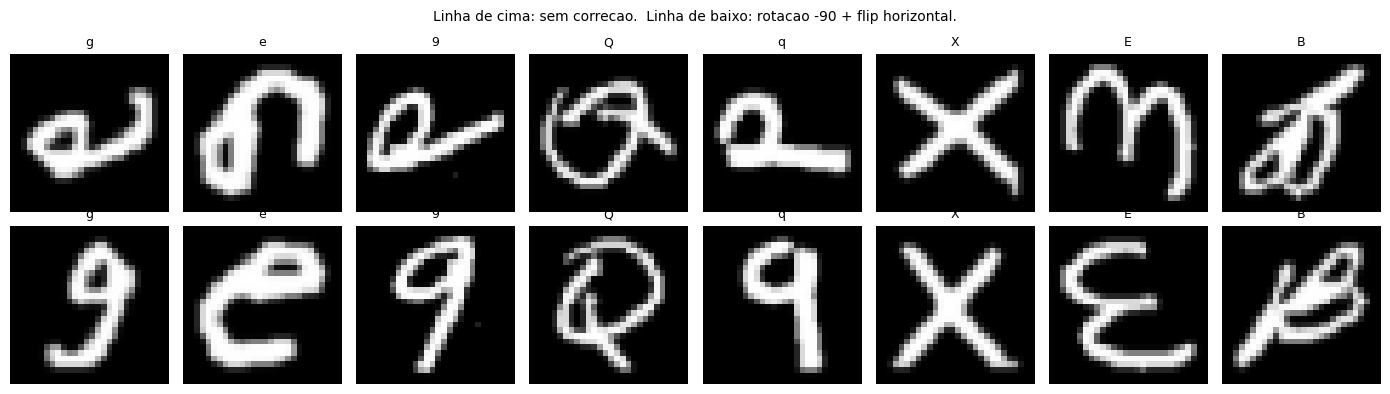

In [4]:
ds_sem_correcao = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False,
    download=True, transform=T.ToTensor(),
)
ds_com_correcao = EMNISTCorrigido(ds_sem_correcao)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    img_sem, label = ds_sem_correcao[i]
    img_com, _ = ds_com_correcao[i]
    axes[0, i].imshow(img_sem.squeeze().numpy(), cmap="gray")
    axes[0, i].set_title(ds_sem_correcao.classes[label], fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(img_com.squeeze().numpy(), cmap="gray")
    axes[1, i].set_title(ds_sem_correcao.classes[label], fontsize=9)
    axes[1, i].axis("off")
plt.suptitle("Linha de cima: sem correcao.  Linha de baixo: rotacao -90 + flip horizontal.", fontsize=10)
plt.tight_layout()
plt.show()


### 2.4 Transform completo e carregamento do dataset

Agora definimos o transform final e carregamos os datasets de treino e teste
do EMNIST Balanced. Em seguida, separamos 10% do treino para formar
um conjunto de validação, como no notebook de Fashion MNIST.


In [ ]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((MEDIA,), (DESVIO,)),
])

treino_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True,
    download=True, transform=transform,
)
treino_full = EMNISTCorrigido(treino_full)

teste_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False,
    download=True, transform=transform,
)
teste_ds = EMNISTCorrigido(teste_ds)

#split treino / validacao (90 / 10)
n_val = int(0.10 * len(treino_full))
n_treino = len(treino_full) - n_val
treino_ds, val_ds = random_split(
    treino_full, [n_treino, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

#lista de classes (pegamos do dataset base, nao do wrapper)
CLASSES = treino_full.base.classes
N_CLASSES = len(CLASSES)

print(f"Treino     : {len(treino_ds)}")
print(f"Validacao  : {len(val_ds)}")
print(f"Teste      : {len(teste_ds)}")
print(f"Classes    : {N_CLASSES}")


Treino     : 101520
Validacao  : 11280
Teste      : 18800
Classes    : 47


### 2.5 DataLoaders

In [ ]:
BATCH = 128

train_loader = DataLoader(treino_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)
test_loader = DataLoader(teste_ds, batch_size=BATCH, shuffle=False, num_workers=0)

Xb, yb = next(iter(train_loader))
print(f"Shape do batch: X = {Xb.shape}, y = {yb.shape}")
print(f"Range de pixel (normalizado): [{Xb.min():.3f}, {Xb.max():.3f}]")


Shape do batch: X = torch.Size([128, 1, 28, 28]), y = torch.Size([128])
Range de pixel (normalizado): [-0.525, 2.475]


### 2.6 Visualização de amostras

Mostramos 20 imagens do batch, ja normalizadas, com o rótulo correto
em cima. Para exibir as imagens visualmente desfazemos a normalização
(multiplicamos pelo desvio e somamos a media).


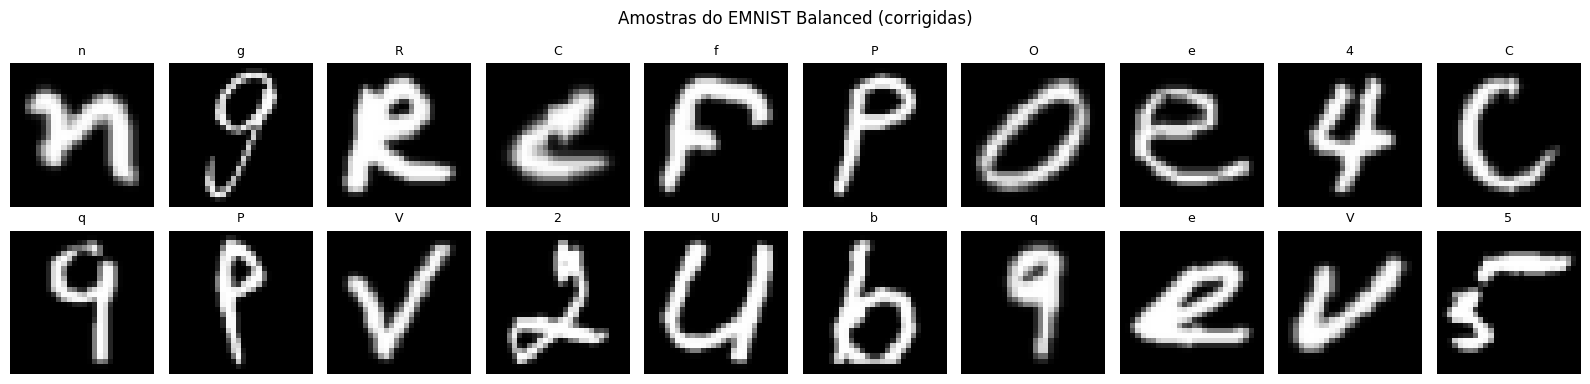

In [7]:
def desnormalizar(t):
    return t * DESVIO + MEDIA

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASSES[yb[i].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Amostras do EMNIST Balanced (corrigidas)")
plt.tight_layout()
plt.show()


## 3. Definicao dos modelos

O enunciado pede **duas arquiteturas**. Criei duas MLPs que compartilham o mesmo esqueleto mas diferem num ponto
especifico: a arquitetura B adiciona BatchNorm1d após cada camada
linear. Com isso conseguimos isolar o efeito da normalização por
batch.

Ambas as arquiteturas usam as mesmas dimensões de camada
(784 -> 256 -> 128 -> 47) para que a comparacao seja justa.


In [8]:
class MLP_A(nn.Module):
    """
    Arquitetura A: MLP simples com ReLU e Dropout.
    784 -> 256 -> 128 -> 47
    """

    def __init__(self, n_classes):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.rede(x)


class MLP_B(nn.Module):
    """
    Arquitetura B: mesma topologia da A, mas com BatchNorm1d apos
    cada camada linear. Permite comparar diretamente o impacto da
    normalizacao por batch.
    784 -> 256 -> 128 -> 47
    """

    def __init__(self, n_classes):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.rede(x)


modelo_a = MLP_A(N_CLASSES).to(device)
modelo_b = MLP_B(N_CLASSES).to(device)

print(modelo_a)
print()
print(f"MLP_A - parametros: {sum(p.numel() for p in modelo_a.parameters()):,}")
print(f"MLP_B - parametros: {sum(p.numel() for p in modelo_b.parameters()):,}")


MLP_A(
  (rede): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=47, bias=True)
  )
)

MLP_A - parametros: 239,919
MLP_B - parametros: 240,687


## 4. Loop de treinamento

Definimos duas funções auxiliares, treinar_epoca e avaliar, no
mesmo formato do notebook de TensorBoard da aula. Cada uma faz uma
passada completa sobre um DataLoader e devolve a loss e a acuracia
medias.


In [9]:
def treinar_epoca(modelo, loader, criterio, otimizador):
    modelo.train()
    loss_total, acertos, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)

        otimizador.zero_grad()
        logits = modelo(X)
        loss = criterio(logits, y)
        loss.backward()
        otimizador.step()

        loss_total += loss.item() * X.size(0)
        acertos += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return loss_total / total, acertos / total


def avaliar(modelo, loader, criterio):
    modelo.eval()
    loss_total, acertos, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = modelo(X)
            loss = criterio(logits, y)
            loss_total += loss.item() * X.size(0)
            acertos += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_total / total, acertos / total


Hiperparametros:

- Otimizador: Adam com learning rate 1e-3 e weight_decay 1e-5
  (mesmos valores do notebook de TensorBoard da aula).
- Scheduler: StepLR com step_size 8 e gamma 0.5 (mesmos valores do
  notebook Fashion MNIST da aula).
- Epocas: ate 40, com early stopping de paciencia 5.

O early stopping interrompe o treino quando a perda de validação
não melhora por 5 epocas consecutivas. A lógica é simples: um
contador sem_melhora que incrementa quando a val_loss não cai e
zera quando cai. Quando chega em 5, para o loop.


In [10]:
os.makedirs("checkpoints", exist_ok=True)


def treinar_modelo(modelo, nome, n_epocas=40, paciencia=5):
    criterio = nn.CrossEntropyLoss()
    otimizador = optim.Adam(modelo.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(otimizador, step_size=8, gamma=0.5)

    writer = SummaryWriter(log_dir=f"runs/{nome}")

    historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    melhor_val_loss = float("inf")
    sem_melhora = 0
    caminho_ckpt = f"checkpoints/{nome}_melhor.pth"

    for epoca in range(1, n_epocas + 1):
        tr_loss, tr_acc = treinar_epoca(modelo, train_loader, criterio, otimizador)
        vl_loss, vl_acc = avaliar(modelo, val_loader, criterio)
        scheduler.step()

        historico["train_loss"].append(tr_loss)
        historico["val_loss"].append(vl_loss)
        historico["train_acc"].append(tr_acc)
        historico["val_acc"].append(vl_acc)

        writer.add_scalars("Loss", {"treino": tr_loss, "val": vl_loss}, epoca)
        writer.add_scalars("Acuracia", {"treino": tr_acc, "val": vl_acc}, epoca)
        writer.add_scalar("LR", otimizador.param_groups[0]["lr"], epoca)

        if vl_loss < melhor_val_loss:
            melhor_val_loss = vl_loss
            sem_melhora = 0
            torch.save({
                "epoca": epoca,
                "modelo_state": modelo.state_dict(),
                "otimizador_state": otimizador.state_dict(),
                "val_acc": vl_acc,
                "val_loss": vl_loss,
                "nome": nome,
                "n_classes": N_CLASSES,
            }, caminho_ckpt)
            marca = "[MELHOR]"
        else:
            sem_melhora += 1
            marca = f"[sem melhora {sem_melhora}/{paciencia}]"

        print(f"Epoca {epoca:02d} | treino loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={vl_loss:.4f} acc={vl_acc:.4f} | {marca}")

        if sem_melhora >= paciencia:
            print(f"\nEarly stopping na epoca {epoca}. Val_loss nao melhora ha {paciencia} epocas.")
            break

    writer.close()
    print(f"\nMelhor val_loss = {melhor_val_loss:.4f}. Checkpoint: {caminho_ckpt}")
    return historico


### 4.1 Treinar MLP_A (baseline simples)

In [ ]:
print("Treinando MLP_A...")
historico_a = treinar_modelo(modelo_a, "MLP_A", n_epocas=40, paciencia=5)


Treinando MLP_A...
Epoca 01 | treino loss=1.2769 acc=0.6236 | val loss=0.7252 acc=0.7760 | [MELHOR]
Epoca 02 | treino loss=0.8127 acc=0.7412 | val loss=0.5958 acc=0.8114 | [MELHOR]
Epoca 03 | treino loss=0.7137 acc=0.7697 | val loss=0.5423 acc=0.8239 | [MELHOR]
Epoca 04 | treino loss=0.6630 acc=0.7836 | val loss=0.5326 acc=0.8246 | [MELHOR]
Epoca 05 | treino loss=0.6317 acc=0.7914 | val loss=0.5014 acc=0.8344 | [MELHOR]
Epoca 06 | treino loss=0.6087 acc=0.7981 | val loss=0.4943 acc=0.8365 | [MELHOR]
Epoca 07 | treino loss=0.5889 acc=0.8025 | val loss=0.4815 acc=0.8441 | [MELHOR]
Epoca 08 | treino loss=0.5790 acc=0.8043 | val loss=0.4784 acc=0.8443 | [MELHOR]
Epoca 09 | treino loss=0.5259 acc=0.8214 | val loss=0.4463 acc=0.8520 | [MELHOR]
Epoca 10 | treino loss=0.5065 acc=0.8254 | val loss=0.4415 acc=0.8518 | [MELHOR]
Epoca 11 | treino loss=0.4993 acc=0.8275 | val loss=0.4382 acc=0.8536 | [MELHOR]
Epoca 12 | treino loss=0.4921 acc=0.8293 | val loss=0.4343 acc=0.8550 | [MELHOR]
Epoca 13 

### 4.2 Treinar MLP_B (com BatchNorm)

In [23]:
print("Treinando MLP_B...")
historico_b = treinar_modelo(modelo_b, "MLP_B", n_epocas=40, paciencia=8)


Treinando MLP_B...
Epoca 01 | treino loss=0.4819 acc=0.8308 | val loss=0.4263 acc=0.8585 | [MELHOR]
Epoca 02 | treino loss=0.4844 acc=0.8324 | val loss=0.4271 acc=0.8567 | [sem melhora 1/8]
Epoca 03 | treino loss=0.4863 acc=0.8305 | val loss=0.4255 acc=0.8550 | [MELHOR]
Epoca 04 | treino loss=0.4779 acc=0.8325 | val loss=0.4217 acc=0.8582 | [MELHOR]
Epoca 05 | treino loss=0.4793 acc=0.8320 | val loss=0.4204 acc=0.8598 | [MELHOR]
Epoca 06 | treino loss=0.4749 acc=0.8331 | val loss=0.4208 acc=0.8594 | [sem melhora 1/8]
Epoca 07 | treino loss=0.4695 acc=0.8356 | val loss=0.4198 acc=0.8591 | [MELHOR]
Epoca 08 | treino loss=0.4674 acc=0.8373 | val loss=0.4239 acc=0.8572 | [sem melhora 1/8]
Epoca 09 | treino loss=0.4414 acc=0.8441 | val loss=0.4109 acc=0.8619 | [MELHOR]
Epoca 10 | treino loss=0.4342 acc=0.8457 | val loss=0.4057 acc=0.8641 | [MELHOR]
Epoca 11 | treino loss=0.4263 acc=0.8472 | val loss=0.4061 acc=0.8645 | [sem melhora 1/8]
Epoca 12 | treino loss=0.4247 acc=0.8485 | val loss=0.

## 5. Gráficos de loss e acurácia por época

Plotamos as duas arquiteturas lado a lado para comparar visualmente
a convergência. A linha tracejada representa o treino, a linha
continua representa a validação.


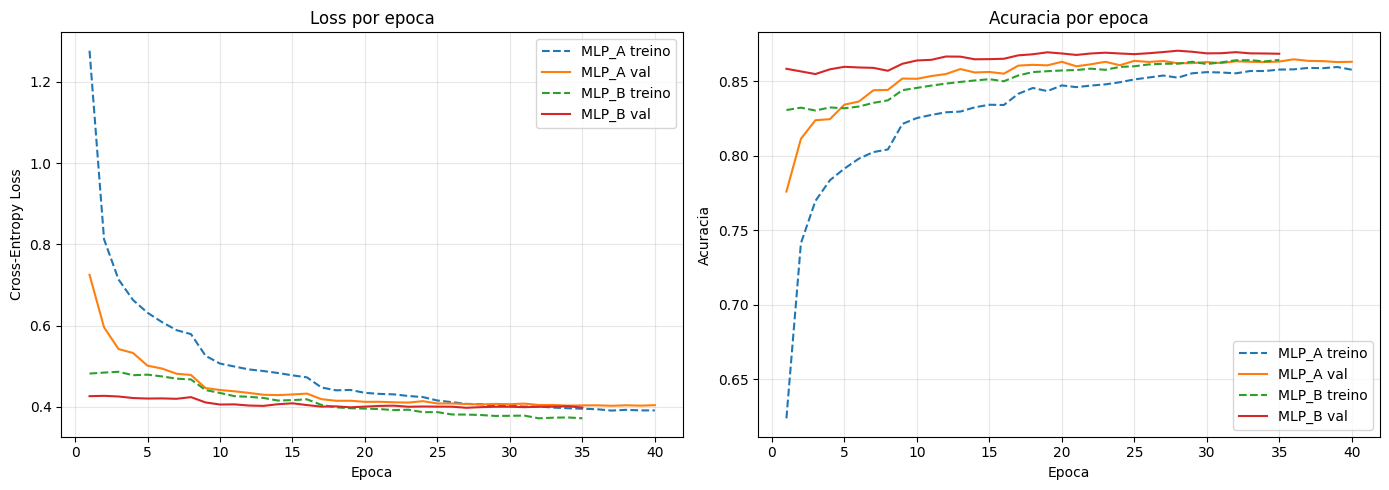

In [24]:
def plotar_historico(hist_a, hist_b):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #pode acontecer de A e B pararem em epocas diferentes (early stopping).
    ep_a = range(1, len(hist_a["train_loss"]) + 1)
    ep_b = range(1, len(hist_b["train_loss"]) + 1)

    axes[0].plot(ep_a, hist_a["train_loss"], "--", label="MLP_A treino")
    axes[0].plot(ep_a, hist_a["val_loss"],         label="MLP_A val")
    axes[0].plot(ep_b, hist_b["train_loss"], "--", label="MLP_B treino")
    axes[0].plot(ep_b, hist_b["val_loss"],         label="MLP_B val")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Loss por epoca")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep_a, hist_a["train_acc"], "--", label="MLP_A treino")
    axes[1].plot(ep_a, hist_a["val_acc"],         label="MLP_A val")
    axes[1].plot(ep_b, hist_b["train_acc"], "--", label="MLP_B treino")
    axes[1].plot(ep_b, hist_b["val_acc"],         label="MLP_B val")
    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("Acuracia")
    axes[1].set_title("Acuracia por epoca")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("graficos_treinamento.png", dpi=150, bbox_inches="tight")
    plt.show()


plotar_historico(historico_a, historico_b)


## 6. Carregar o melhor modelo do disco (checkpoint)

O enunciado exige que a avaliacao final seja feita com o modelo
carregado do arquivo .pth, e não com o modelo em memória. 
Para melhor usabilidade, irei utilizar esse mesmo .pth para o app.py subindo no GitHub.


In [25]:
def carregar_modelo(classe_modelo, caminho_ckpt):
    checkpoint = torch.load(caminho_ckpt, map_location=device, weights_only=False)
    modelo = classe_modelo(checkpoint["n_classes"]).to(device)
    modelo.load_state_dict(checkpoint["modelo_state"])
    modelo.eval()
    print(f"Carregado: {caminho_ckpt}")
    print(f"  Melhor epoca : {checkpoint['epoca']}")
    print(f"  Val acc      : {checkpoint['val_acc']:.4f}")
    print(f"  Val loss     : {checkpoint['val_loss']:.4f}")
    return modelo


modelo_a_carregado = carregar_modelo(MLP_A, "checkpoints/MLP_A_melhor.pth")
print()
modelo_b_carregado = carregar_modelo(MLP_B, "checkpoints/MLP_B_melhor.pth")


Carregado: checkpoints/MLP_A_melhor.pth
  Melhor epoca : 37
  Val acc      : 0.8638
  Val loss     : 0.4026

Carregado: checkpoints/MLP_B_melhor.pth
  Melhor epoca : 27
  Val acc      : 0.8698
  Val loss     : 0.3977


## 7. Avaliação no conjunto de teste

Rodamos os dois modelos carregados sobre o conjunto de teste
(18.800 imagens), calculamos a acuracia e imprimimos o
classification_report do scikit-learn com as 47 classes.


In [26]:
def avaliar_teste(modelo):
    todas_preds, todos_reais = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            logits = modelo(X)
            preds = logits.argmax(1).cpu().numpy()
            todas_preds.extend(preds)
            todos_reais.extend(y.numpy())
    return np.array(todas_preds), np.array(todos_reais)


preds_a, reais_a = avaliar_teste(modelo_a_carregado)
preds_b, reais_b = avaliar_teste(modelo_b_carregado)

acc_a = accuracy_score(reais_a, preds_a)
acc_b = accuracy_score(reais_b, preds_b)

print(f"MLP_A - acuracia no teste: {acc_a*100:.2f}%")
print(f"MLP_B - acuracia no teste: {acc_b*100:.2f}%")
print()
print("Classification report do MLP_B:")
print(classification_report(reais_b, preds_b, target_names=CLASSES, digits=4))


MLP_A - acuracia no teste: 85.87%
MLP_B - acuracia no teste: 86.20%

Classification report do MLP_B:
              precision    recall  f1-score   support

           0     0.6548    0.6875    0.6707       400
           1     0.5424    0.7675    0.6356       400
           2     0.9055    0.8625    0.8835       400
           3     0.9646    0.9550    0.9598       400
           4     0.9045    0.9000    0.9023       400
           5     0.9139    0.8225    0.8658       400
           6     0.9051    0.9300    0.9174       400
           7     0.9559    0.9750    0.9653       400
           8     0.9057    0.9125    0.9091       400
           9     0.6343    0.8500    0.7265       400
           A     0.9450    0.9450    0.9450       400
           B     0.9322    0.9275    0.9298       400
           C     0.9287    0.9450    0.9368       400
           D     0.8959    0.8825    0.8892       400
           E     0.9573    0.9525    0.9549       400
           F     0.7000    0.5425 

### 7.1 Matriz de confusão

Com 47 classes a matriz fica densa, o seaborn.heatmap gera um mapa de calor legivel, com
cores mais intensas nas celulas de maior valor. Normalizamos cada
linha pela soma dela, para que cada celula represente a fração das
amostras reais da classe X que foram classificadas como Y.

Plotamos as duas matrizes para poder comparar as duas arquiteturas.


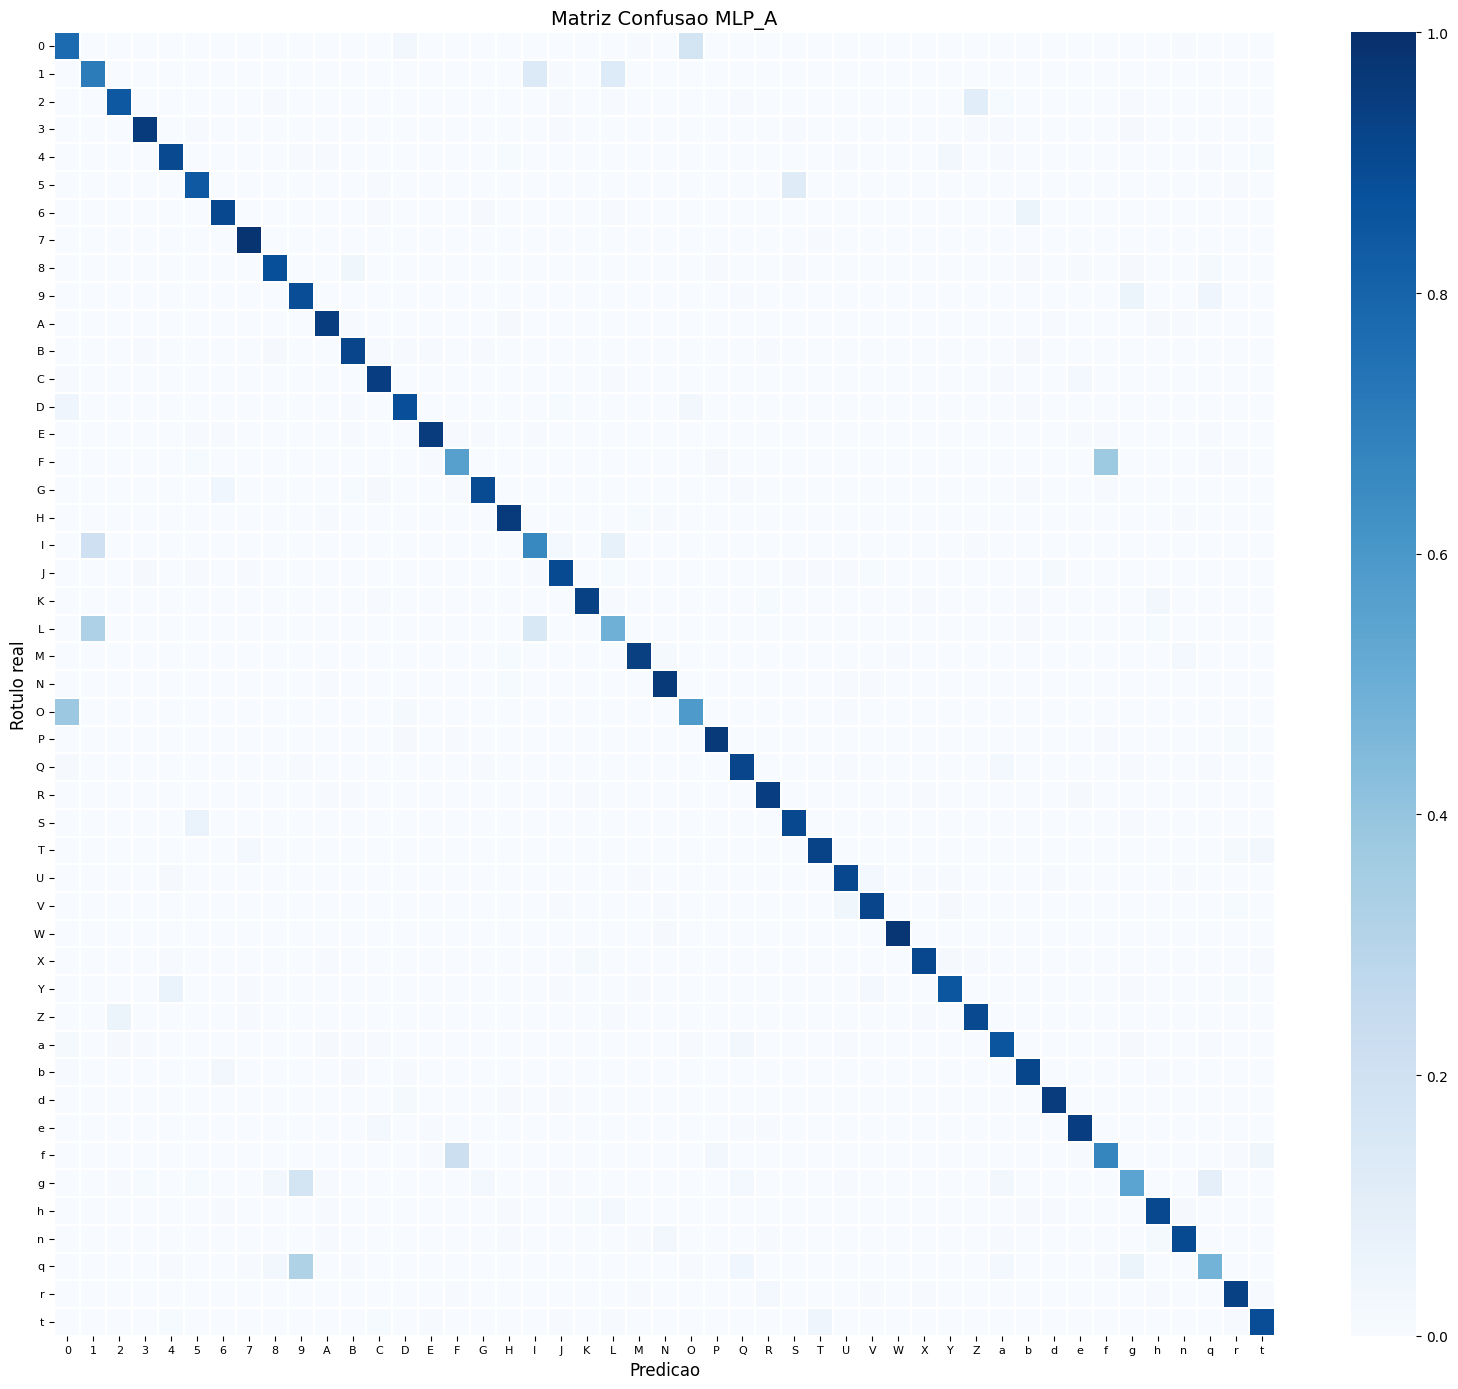

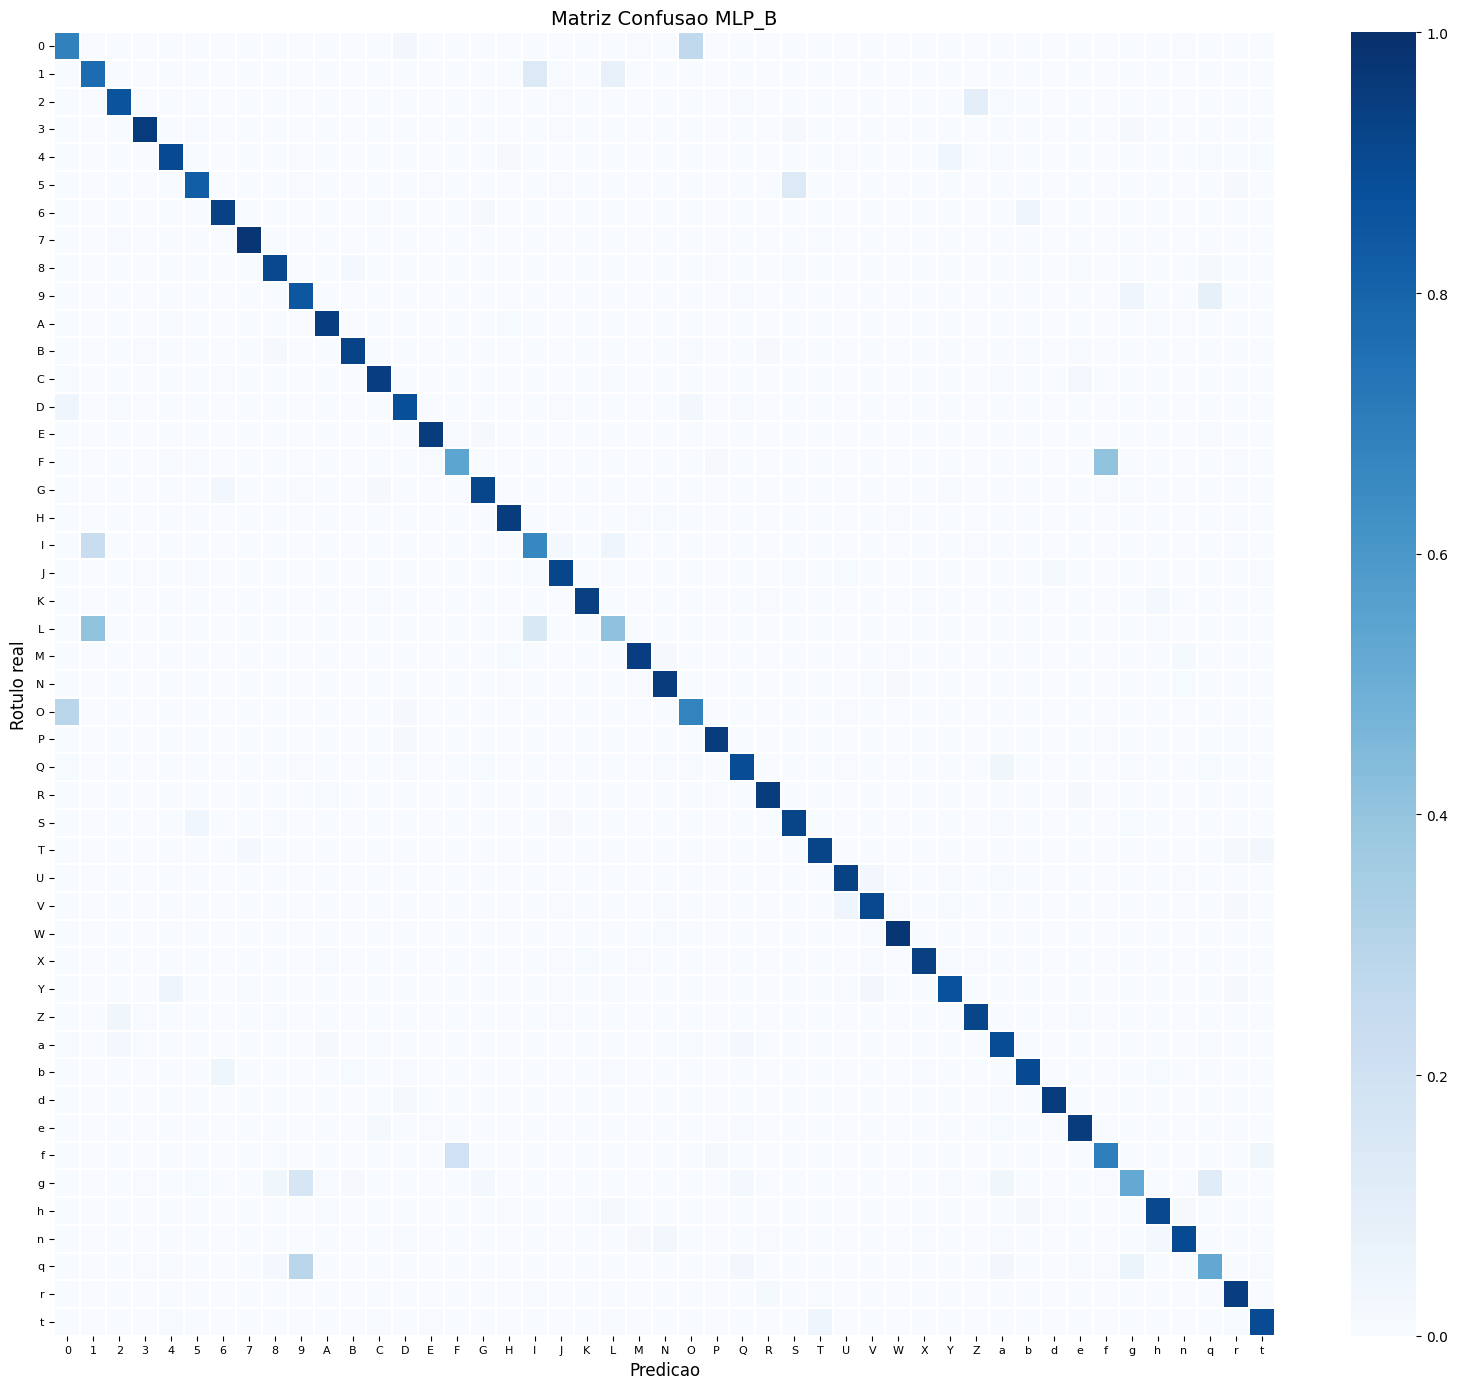

In [27]:
def plotar_matriz_confusao(y_true, y_pred, classes, titulo):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        cm_norm, annot=False, cmap="Blues",
        xticklabels=classes, yticklabels=classes,
        ax=ax, linewidths=0.3, vmin=0, vmax=1,
    )
    ax.set_xlabel("Predicao", fontsize=12)
    ax.set_ylabel("Rotulo real", fontsize=12)
    ax.set_title(titulo, fontsize=14)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8, rotation=0)
    plt.tight_layout()
    nome_arquivo = titulo.replace(" ", "_").replace("-", "")
    plt.savefig(f"matriz_confusao_{nome_arquivo}.png", dpi=150, bbox_inches="tight")
    plt.show()


plotar_matriz_confusao(reais_a, preds_a, CLASSES, "Matriz Confusao MLP_A")
plotar_matriz_confusao(reais_b, preds_b, CLASSES, "Matriz Confusao MLP_B")


### 7.2 Test-Time Augmentation (TTA)

Para tentar aumentar a acurácia, utilizaremos o Test-Time Augmentation, ou TTA que, 
em vez de passar a imagem uma unica vez pela rede, passa também algumas versões levemente 
deslocadas e tiramos a media das probabilidades Softmax. Se o modelo é robusto,
os resultados batem e a media é estável, mas se ele esta indeciso sobre
uma imagem, a média suaviza a indecisão.

Implementação:

1. Geramos 4 versoes da imagem deslocadas em 1 pixel (cima, baixo,
   esquerda, direita) usando torch.roll.
2. Passamos a imagem original e as 4 versões pela rede.
3. Calculamos a Softmax de cada uma.
4. Tiramos a média das 5 distribuições de probabilidade.
5. Usamos argmax sobre a média para obter a predição final.


In [28]:
def predizer_com_tta(modelo, X):
    """
    Passa a imagem original + 4 versoes deslocadas em 1 pixel pela
    rede, retorna a media das probabilidades Softmax.
    X tem shape [B, 1, 28, 28]. Retorna shape [B, n_classes].
    """
    modelo.eval()
    versoes = [X]
    for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
        versoes.append(torch.roll(X, shifts=(dy, dx), dims=(2, 3)))

    with torch.no_grad():
        probs_lista = [torch.softmax(modelo(v), dim=1) for v in versoes]
        probs_media = torch.stack(probs_lista, dim=0).mean(dim=0)
    return probs_media


def avaliar_com_tta(modelo, loader):
    preds, reais = [], []
    for X, y in loader:
        X = X.to(device)
        probs = predizer_com_tta(modelo, X)
        preds.extend(probs.argmax(1).cpu().numpy())
        reais.extend(y.numpy())
    return np.array(preds), np.array(reais)


print("Avaliando MLP_B com TTA...")
preds_b_tta, reais_b_tta = avaliar_com_tta(modelo_b_carregado, test_loader)
acc_b_tta = accuracy_score(reais_b_tta, preds_b_tta)
print(f"MLP_B puro: acc teste = {acc_b*100:.2f}%")
print(f"MLP_B com TTA: acc teste = {acc_b_tta*100:.2f}%")
print(f"Ganho do TTA vs MLP_B: {(acc_b_tta - acc_b)*100:+.2f} pp")


Avaliando MLP_B com TTA...
MLP_B puro: acc teste = 86.20%
MLP_B com TTA: acc teste = 86.48%
Ganho do TTA vs MLP_B: +0.28 pp


### 7.3 Ensemble A + B

Ensemble é outra técnica nao exige retreinamento: juntar
as saídas de dois ou mais modelos para formar uma predição unica. A
forma mais comum e a media aritmetica das probabilidades Softmax.

Cada arquitetura erra em imagens diferentes. Ao combinar as duas, 
alguns erros individuais são cobertos pela confiança da outra rede, 
e o resultado tende a ser igual ou melhor que o melhor modelo sozinho.


In [29]:
def predizer_ensemble(modelos, X):
    """
    Passa a imagem por cada modelo, retorna a media das probabilidades
    Softmax.
    """
    for m in modelos:
        m.eval()

    with torch.no_grad():
        probs_lista = [torch.softmax(m(X), dim=1) for m in modelos]
        probs_media = torch.stack(probs_lista, dim=0).mean(dim=0)
    return probs_media


def avaliar_ensemble(modelos, loader):
    preds, reais = [], []
    for X, y in loader:
        X = X.to(device)
        probs = predizer_ensemble(modelos, X)
        preds.extend(probs.argmax(1).cpu().numpy())
        reais.extend(y.numpy())
    return np.array(preds), np.array(reais)


print("Avaliando ensemble A + B...")
preds_ens, reais_ens = avaliar_ensemble(
    [modelo_a_carregado, modelo_b_carregado], test_loader,
)
acc_ens = accuracy_score(reais_ens, preds_ens)

print(f"MLP_A puro: acc teste = {acc_a*100:.2f}%")
print(f"MLP_B puro: acc teste = {acc_b*100:.2f}%")
print(f"Ensemble A+B: acc teste = {acc_ens*100:.2f}%")
print(f"Ganho do ensemble vs B: {(acc_ens - acc_b)*100:+.2f} pp")


Avaliando ensemble A + B...
MLP_A puro: acc teste = 85.87%
MLP_B puro: acc teste = 86.20%
Ensemble A+B: acc teste = 86.53%
Ganho do ensemble vs B: +0.33 pp


### 7.4 Ensemble + TTA combinados

As duas técnicas são independentes entre si, então podem ser
aplicadas em conjunto: cada um dos dois modelos do ensemble é
avaliado com TTA, e depois as probabilidades médias são combinadas.

E o setup com maior custo de inferência (5 versoes vezes 2 modelos =
10 forward passes por imagem), mas também, na teoria, daria o melhor resultado final.

In [30]:
def predizer_ensemble_tta(modelos, X):
    """
    Para cada modelo, roda TTA. Depois tira a media entre os modelos.
    """
    probs_por_modelo = [predizer_com_tta(m, X) for m in modelos]
    return torch.stack(probs_por_modelo, dim=0).mean(dim=0)


def avaliar_ensemble_tta(modelos, loader):
    preds, reais = [], []
    for X, y in loader:
        X = X.to(device)
        probs = predizer_ensemble_tta(modelos, X)
        preds.extend(probs.argmax(1).cpu().numpy())
        reais.extend(y.numpy())
    return np.array(preds), np.array(reais)


print("Avaliando ensemble A + B com TTA...")
preds_final, reais_final = avaliar_ensemble_tta(
    [modelo_a_carregado, modelo_b_carregado], test_loader,
)
acc_final = accuracy_score(reais_final, preds_final)

print()
print("Comparativo final:")
print(f"{'MLP_A puro':<28} acc = {acc_a*100:.2f}%")
print(f"{'MLP_B puro':<28} acc = {acc_b*100:.2f}%")
print(f"{'MLP_B + TTA':<28} acc = {acc_b_tta*100:.2f}%  ({(acc_b_tta - acc_b)*100:+.2f} pp)")
print(f"{'Ensemble A+B':<28} acc = {acc_ens*100:.2f}%  ({(acc_ens - acc_b)*100:+.2f} pp)")
print(f"{'Ensemble A+B com TTA':<28} acc = {acc_final*100:.2f}%  ({(acc_final - acc_b)*100:+.2f} pp)")


Avaliando ensemble A + B com TTA...

Comparativo final:
MLP_A puro                   acc = 85.87%
MLP_B puro                   acc = 86.20%
MLP_B + TTA                  acc = 86.48%  (+0.28 pp)
Ensemble A+B                 acc = 86.53%  (+0.33 pp)
Ensemble A+B com TTA         acc = 86.60%  (+0.40 pp)


## 8. Exemplos de predição (acertos e erros)

Pelo enunciado (item 3.5) precisamos de pelo menos 10 exemplos de
predicao visualizados. Mostramos 10 acertos (titulo verde) e 10
erros (titulo vermelho) do MLP_B, com a probabilidade Softmax da
classe prevista.


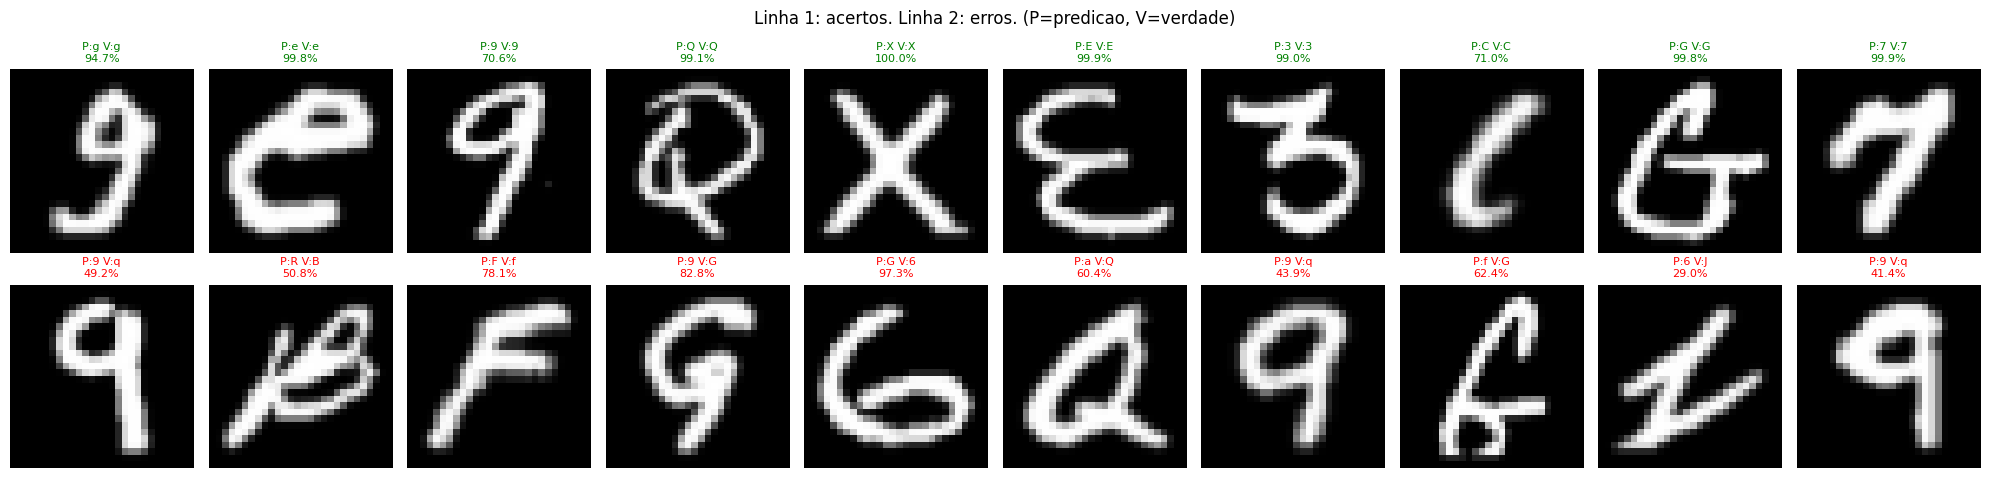

In [31]:
def visualizar_predicoes(modelo, n_acertos=10, n_erros=10):
    modelo.eval()
    acertos_img, acertos_info = [], []
    erros_img, erros_info = [], []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            logits = modelo(X)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

            for i in range(X.size(0)):
                real = int(y[i])
                pred = int(preds[i])
                conf = float(probs[i, pred])
                img = X[i].cpu()

                if pred == real and len(acertos_img) < n_acertos:
                    acertos_img.append(img)
                    acertos_info.append((CLASSES[pred], CLASSES[real], conf))
                elif pred != real and len(erros_img) < n_erros:
                    erros_img.append(img)
                    erros_info.append((CLASSES[pred], CLASSES[real], conf))

                if len(acertos_img) >= n_acertos and len(erros_img) >= n_erros:
                    break
            if len(acertos_img) >= n_acertos and len(erros_img) >= n_erros:
                break

    n_cols = max(n_acertos, n_erros)
    fig, axes = plt.subplots(2, n_cols, figsize=(20, 5))

    for i in range(n_acertos):
        img_vis = desnormalizar(acertos_img[i]).squeeze().numpy()
        pred, real, conf = acertos_info[i]
        axes[0, i].imshow(img_vis, cmap="gray")
        axes[0, i].set_title(f"P:{pred} V:{real}\n{conf*100:.1f}%", fontsize=8, color="green")
        axes[0, i].axis("off")

    for i in range(n_erros):
        img_vis = desnormalizar(erros_img[i]).squeeze().numpy()
        pred, real, conf = erros_info[i]
        axes[1, i].imshow(img_vis, cmap="gray")
        axes[1, i].set_title(f"P:{pred} V:{real}\n{conf*100:.1f}%", fontsize=8, color="red")
        axes[1, i].axis("off")

    plt.suptitle("Linha 1: acertos. Linha 2: erros. (P=predicao, V=verdade)")
    plt.tight_layout()
    plt.savefig("predicoes_exemplos.png", dpi=150, bbox_inches="tight")
    plt.show()


visualizar_predicoes(modelo_b_carregado)


## 9. TensorBoard

terminal:
```bash
tensorboard --logdir=runs
```
http://localhost:6006 ou rode abaixo no notebook:

In [32]:
%load_ext tensorboard
%tensorboard --logdir runs


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 41564), started 0:37:37 ago. (Use '!kill 41564' to kill it.)

## 10. Resumo comparativo

Consolidação final das duas arquiteturas e das técnicas de inferência.


In [33]:
print(f"MLP_A (baseline): acc teste = {acc_a*100:.2f}%")
print(f"MLP_B (com BatchNorm): acc teste = {acc_b*100:.2f}%")
print(f"MLP_B + TTA: acc teste = {acc_b_tta*100:.2f}%")
print(f"Ensemble A+B: acc teste = {acc_ens*100:.2f}%")
print(f"Ensemble A+B com TTA: acc teste = {acc_final*100:.2f}%")
print()
print(f"Ganho do BatchNorm (B vs A): {(acc_b - acc_a)*100:+.2f} pp")
print(f"Ganho do TTA (B+TTA vs B): {(acc_b_tta - acc_b)*100:+.2f} pp")
print(f"Ganho do ensemble (A+B vs B): {(acc_ens - acc_b)*100:+.2f} pp")
print(f"Ganho combinado (A+B+TTA vs B): {(acc_final - acc_b)*100:+.2f} pp")

MLP_A (baseline): acc teste = 85.87%
MLP_B (com BatchNorm): acc teste = 86.20%
MLP_B + TTA: acc teste = 86.48%
Ensemble A+B: acc teste = 86.53%
Ensemble A+B com TTA: acc teste = 86.60%

Ganho do BatchNorm (B vs A): +0.33 pp
Ganho do TTA (B+TTA vs B): +0.28 pp
Ganho do ensemble (A+B vs B): +0.33 pp
Ganho combinado (A+B+TTA vs B): +0.40 pp
